# Customer Churn Analysis

**Research questions**
1. Which customer attributes most strongly predict churn?
2. Is there a behavioral signature (disengagement + support friction) that separates churners from retainers?
3. How much do data-quality issues (sentinels, case inconsistency, missing values) affect conclusions?

**Data source:** `customer churn.csv` (10,300 rows x 10 columns)

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
OUT = Path('.')
SRC = '/Users/sanjivda/Desktop/customer_churn/customer churn.csv'
df_raw = pd.read_csv(SRC)
print('Raw shape:', df_raw.shape)
df_raw.head()

Raw shape: (10300, 10)


,Customer_ID,Gender,Region,Subscription_Plan,Payment_Method,Age,Days_Since_Last_Login,Customer_Service_Calls,Monthly_Spend,Churn
0,10001,Male,East,Basic,PayPal,27.0,27,1,61.08,0
1,10002,Unknown,West,Pro,PayPal,55.0,146,2,73.09,0
2,10003,Female,West,Pro,E-Wallet,NaN,147,2,116.30,1
3,10004,Female,south,Basic,Credit Card,NaN,34,1,0.58,1
4,10005,Male,North,Basic,Crypto,30.0,146,3,46.35,1


## 1. Data quality audit

The raw data has several quality issues visible on first inspection:
- `Region` and `Subscription_Plan` mix title case and lowercase (`South` vs `south`, `Basic` vs `BASIC`).
- `Age` contains impossible values (min = -10, max = 150).
- `Monthly_Spend` contains sentinel `99999.99` and negative values.
- `Payment_Method`, `Age`, `Monthly_Spend` have missing values.

In [2]:
print('Missing values:')
print(df_raw.isna().sum())
print()
print('Region raw:', df_raw['Region'].value_counts().to_dict())
print()
print('Subscription_Plan raw:', df_raw['Subscription_Plan'].value_counts().to_dict())
print()
print('Age range:', df_raw['Age'].min(), '->', df_raw['Age'].max())
print('Monthly_Spend range:', df_raw['Monthly_Spend'].min(), '->', df_raw['Monthly_Spend'].max())

Missing values:
Customer_ID                  0
Gender                       0
Region                       0
Subscription_Plan            0
Payment_Method             725
Age                       1033
Days_Since_Last_Login        0
Customer_Service_Calls       0
Monthly_Spend              514
Churn                        0
dtype: int64

Region raw: {'South': 2350, 'East': 2334, 'West': 2330, 'North': 2285, 'south': 257, 'west': 257, 'east': 252, 'north': 235}

Subscription_Plan raw: {'Basic': 4517, 'Pro': 2886, 'Plus': 1862, 'BASIC': 486, 'PRO': 330, 'PLUS': 219}

Age range: -10.0 -> 150.0
Monthly_Spend range: -10.0 -> 99999.99


## 2. Cleaning

- Normalize categorical case to Title Case.
- Flag out-of-range numeric values (Age outside [0,100], Spend outside [0,10000]) as missing.
- Impute numerics with the median; fill missing `Payment_Method` with `'Unknown'`.

In [3]:
df = df_raw.copy()
df['Region'] = df['Region'].str.title()
df['Subscription_Plan'] = df['Subscription_Plan'].str.title()
df.loc[(df['Age'] < 0) | (df['Age'] > 100), 'Age'] = np.nan
df.loc[(df['Monthly_Spend'] < 0) | (df['Monthly_Spend'] > 10000), 'Monthly_Spend'] = np.nan
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Monthly_Spend'] = df['Monthly_Spend'].fillna(df['Monthly_Spend'].median())
df['Payment_Method'] = df['Payment_Method'].fillna('Unknown')
print('Cleaned churn rate:', round(df['Churn'].mean(), 3))
df[['Age','Monthly_Spend']].describe()

Cleaned churn rate: 0.762


,Age,Monthly_Spend
count,10300.000000,10300.000000
mean,33.330971,75.351624
std,9.458608,57.892547
min,0.000000,0.000000
25%,27.000000,29.260000
50%,33.000000,66.520000
75%,39.000000,112.152500
max,70.000000,311.390000


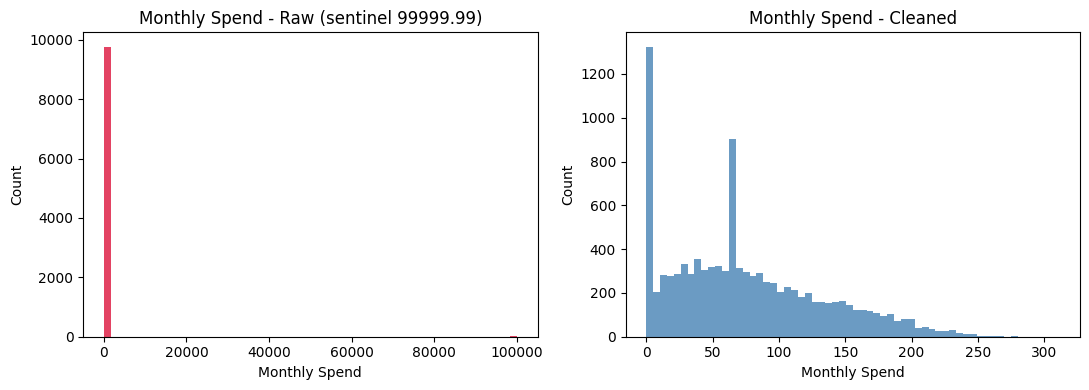

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df_raw['Monthly_Spend'].dropna(), bins=60, color='crimson', alpha=0.8)
axes[0].set_title('Monthly Spend - Raw (sentinel 99999.99)')
axes[0].set_xlabel('Monthly Spend'); axes[0].set_ylabel('Count')
axes[1].hist(df['Monthly_Spend'], bins=60, color='steelblue', alpha=0.8)
axes[1].set_title('Monthly Spend - Cleaned')
axes[1].set_xlabel('Monthly Spend'); axes[1].set_ylabel('Count')
plt.tight_layout()
plt.savefig(OUT / 'fig1_data_quality.pdf', bbox_inches='tight')
plt.savefig(OUT / 'fig1_data_quality.png', bbox_inches='tight', dpi=150)
plt.show()

## 3. Churn rate by category

Chi-square tests compare the churn distribution across categorical groups. `Region` and `Subscription_Plan` show strong association with churn; `Gender` and `Payment_Method` do not.

In [5]:
for col in ['Gender','Region','Subscription_Plan','Payment_Method']:
    ct = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f'{col}: chi2={chi2:.2f}  dof={dof}  p={p:.3g}')

Gender: chi2=1.39  dof=3  p=0.708
Region: chi2=41.50  dof=3  p=5.12e-09
Subscription_Plan: chi2=152.85  dof=2  p=6.45e-34
Payment_Method: chi2=7.15  dof=4  p=0.128


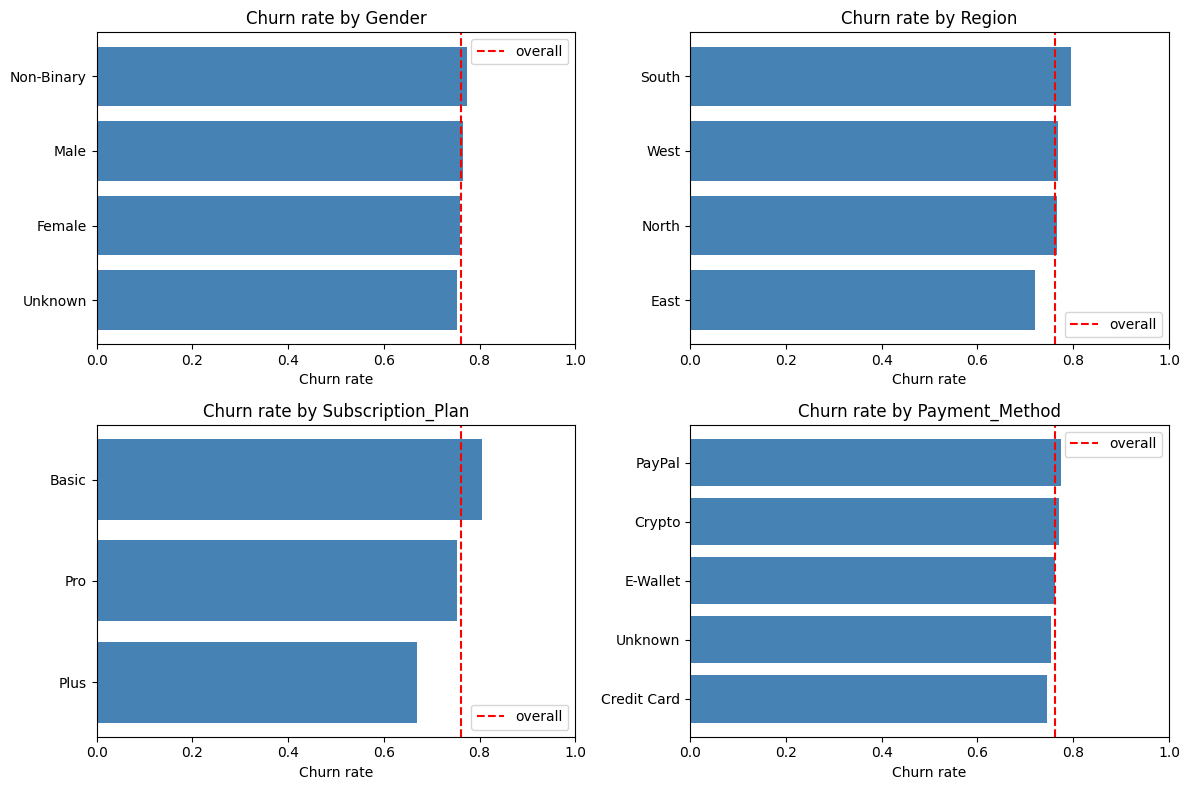

In [6]:
cat_cols = ['Gender','Region','Subscription_Plan','Payment_Method']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, cat_cols):
    rates = df.groupby(col)['Churn'].mean().sort_values()
    ax.barh(rates.index, rates.values, color='steelblue')
    ax.axvline(df['Churn'].mean(), color='red', linestyle='--', label='overall')
    ax.set_title(f'Churn rate by {col}')
    ax.set_xlabel('Churn rate'); ax.set_xlim(0, 1); ax.legend()
plt.tight_layout()
plt.savefig(OUT / 'fig2_churn_by_category.pdf', bbox_inches='tight')
plt.savefig(OUT / 'fig2_churn_by_category.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Numeric predictors: t-tests and distributions

Welch's t-test compares churners vs. retainers on each numeric feature.

In [7]:
for col in ['Age','Days_Since_Last_Login','Customer_Service_Calls','Monthly_Spend']:
    g1 = df.loc[df['Churn']==1, col]; g0 = df.loc[df['Churn']==0, col]
    t, p = stats.ttest_ind(g1, g0, equal_var=False)
    print(f'{col:25s}  churn_mean={g1.mean():7.2f}  retain_mean={g0.mean():7.2f}  t={t:7.2f}  p={p:.3g}')

Age                        churn_mean=  33.34  retain_mean=  33.29  t=   0.25  p=0.8
Days_Since_Last_Login      churn_mean=  97.08  retain_mean=  65.02  t=  28.73  p=1.62e-166
Customer_Service_Calls     churn_mean=   1.91  retain_mean=   1.39  t=  18.57  p=2.33e-74
Monthly_Spend              churn_mean=  70.60  retain_mean=  90.55  t= -14.35  p=1.57e-45


/tmp/ipykernel_32367/1450953807.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=['Retain', 'Churn'], showfliers=False)
/tmp/ipykernel_32367/1450953807.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=['Retain', 'Churn'], showfliers=False)
/tmp/ipykernel_32367/1450953807.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=['Retain', 'Churn'], showfliers=False)
/tmp/ipykernel_32367/1450953807.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name wi

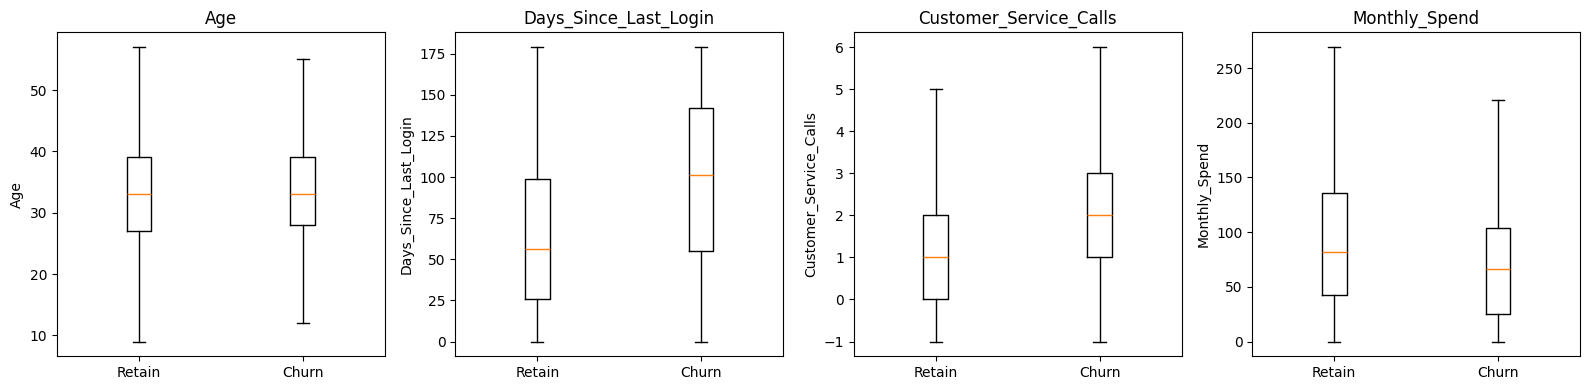

In [8]:
num_cols = ['Age','Days_Since_Last_Login','Customer_Service_Calls','Monthly_Spend']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    data = [df.loc[df['Churn']==0, col], df.loc[df['Churn']==1, col]]
    ax.boxplot(data, labels=['Retain', 'Churn'], showfliers=False)
    ax.set_title(col); ax.set_ylabel(col)
plt.tight_layout()
plt.savefig(OUT / 'fig3_numeric_by_churn.pdf', bbox_inches='tight')
plt.savefig(OUT / 'fig3_numeric_by_churn.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Behavioral signature

Does the joint distribution of disengagement (days since last login) and support friction (service calls) separate churners? We bin both variables and plot churn rate per cell.

/tmp/ipykernel_32367/1646163645.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.assign(D=d_bins, C=c_bins).pivot_table(index='C', columns='D', values='Churn', aggfunc='mean')


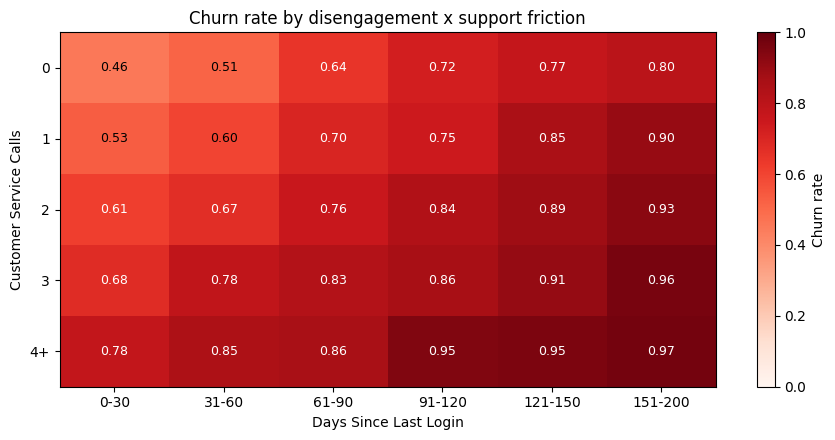

In [9]:
d_bins = pd.cut(df['Days_Since_Last_Login'], bins=[-0.1, 30, 60, 90, 120, 150, 200, 400], labels=['0-30','31-60','61-90','91-120','121-150','151-200','200+'])
c_bins = pd.cut(df['Customer_Service_Calls'], bins=[-0.1, 0, 1, 2, 3, 20], labels=['0','1','2','3','4+'])
pivot = df.assign(D=d_bins, C=c_bins).pivot_table(index='C', columns='D', values='Churn', aggfunc='mean')
fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(pivot.values, aspect='auto', cmap='Reds', vmin=0, vmax=1)
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
ax.set_xlabel('Days Since Last Login'); ax.set_ylabel('Customer Service Calls')
ax.set_title('Churn rate by disengagement x support friction')
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', color='white' if v > 0.6 else 'black', fontsize=9)
fig.colorbar(im, ax=ax, label='Churn rate')
plt.tight_layout()
plt.savefig(OUT / 'fig4_behavior_heatmap.pdf', bbox_inches='tight')
plt.savefig(OUT / 'fig4_behavior_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Predictive models

We fit two models on a 75/25 train/test split:
- Random Forest (300 trees, class-balanced)
- Logistic Regression (standardized features, class-balanced)

We report test-set AUC and feature importance / coefficients.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

cat_cols = ['Gender','Region','Subscription_Plan','Payment_Method']
num_cols = ['Age','Days_Since_Last_Login','Customer_Service_Calls','Monthly_Spend']
X = pd.get_dummies(df[cat_cols + num_cols], columns=cat_cols, drop_first=True)
y = df['Churn']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_tr, y_tr)
p_rf = rf.predict_proba(X_te)[:, 1]
print(f'Random Forest AUC: {roc_auc_score(y_te, p_rf):.4f}')

scaler = StandardScaler()
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(scaler.fit_transform(X_tr), y_tr)
p_lr = lr.predict_proba(scaler.transform(X_te))[:, 1]
print(f'Logistic Regression AUC: {roc_auc_score(y_te, p_lr):.4f}')

Random Forest AUC: 0.7153
Logistic Regression AUC: 0.7204


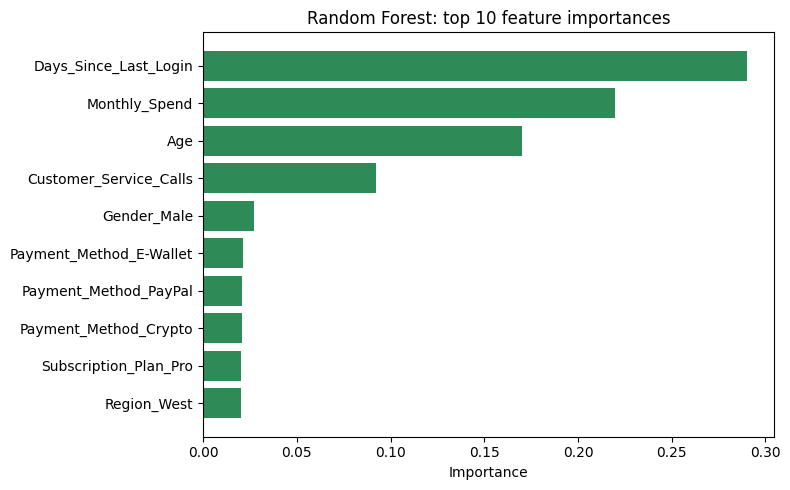

In [11]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True).tail(10)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importances.index, importances.values, color='seagreen')
ax.set_title('Random Forest: top 10 feature importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(OUT / 'fig5_feature_importance.pdf', bbox_inches='tight')
plt.savefig(OUT / 'fig5_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

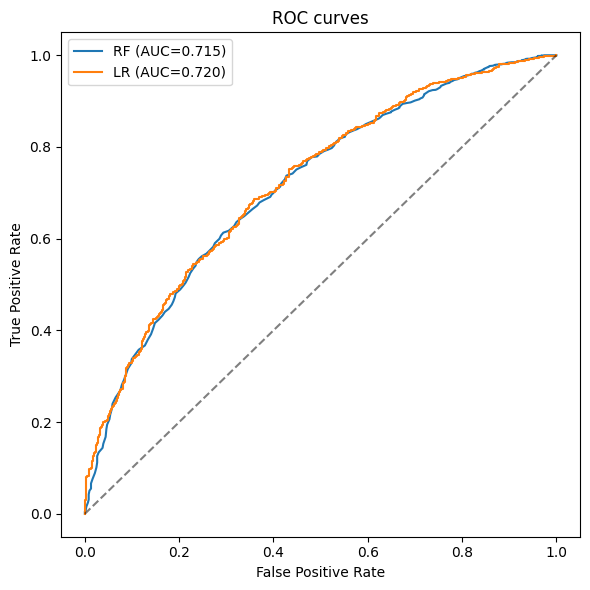

In [12]:
fpr_rf, tpr_rf, _ = roc_curve(y_te, p_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_te, p_lr)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_rf, tpr_rf, label=f'RF (AUC={roc_auc_score(y_te, p_rf):.3f})')
ax.plot(fpr_lr, tpr_lr, label=f'LR (AUC={roc_auc_score(y_te, p_lr):.3f})')
ax.plot([0,1], [0,1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curves'); ax.legend()
plt.tight_layout()
plt.savefig(OUT / 'fig6_roc.pdf', bbox_inches='tight')
plt.savefig(OUT / 'fig6_roc.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Summary

- **Class imbalance:** 76.2% of customers churned - the baseline is already high.
- **Strongest churn drivers:** `Days_Since_Last_Login` (t = 28.7, p ~ 10^-166), `Customer_Service_Calls` (p ~ 10^-74), lower `Monthly_Spend` (p ~ 10^-45).
- **Non-drivers:** `Age` and `Gender` show no statistical relationship with churn.
- **Regional / plan effects:** significant but modest in magnitude.
- **Predictive performance:** AUC ~ 0.72 for both RF and Logistic Regression - a useful but not dominant signal.
- **Data quality matters:** raw data contained sentinels (99999.99), negative values, and case-inconsistent categories that would have produced spurious results without cleaning.